In [24]:
# ============================================================
# Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import matthews_corrcoef

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")


In [25]:
# ============================================================
# Load Dataset
# ============================================================
df = pd.read_csv("creditcard.csv")
print("Initial Dataset Shape:", df.shape)


Initial Dataset Shape: (284807, 31)


In [3]:
# Dataset Information
print("\nDataset Information")
df.info()

print("\nDataset Description")
print(df.describe())



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

In [4]:
# ============================================================
# Missing Values Check
# ============================================================
total_null = df.isnull().sum().sum()

if total_null == 0:
    print("No missing values found.")
else:
    print("Total missing values:", total_null)


No missing values found.


In [5]:
# ============================================================
# Duplicate Removal
# ============================================================
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()

print("Dataset Shape After Duplicate Removal:", df.shape)


Duplicate Rows: 1081
Dataset Shape After Duplicate Removal: (283726, 31)


Class
0    283253
1       473
Name: count, dtype: int64


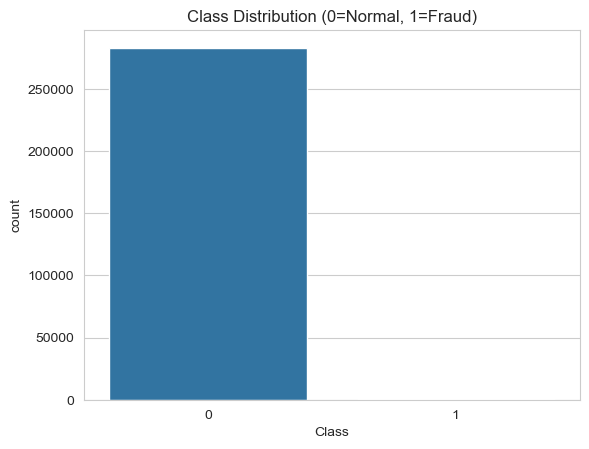

In [6]:
# ============================================================
# Class Distribution
# ============================================================
print(df["Class"].value_counts())

plt.figure()
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0=Normal, 1=Fraud)")
plt.show()


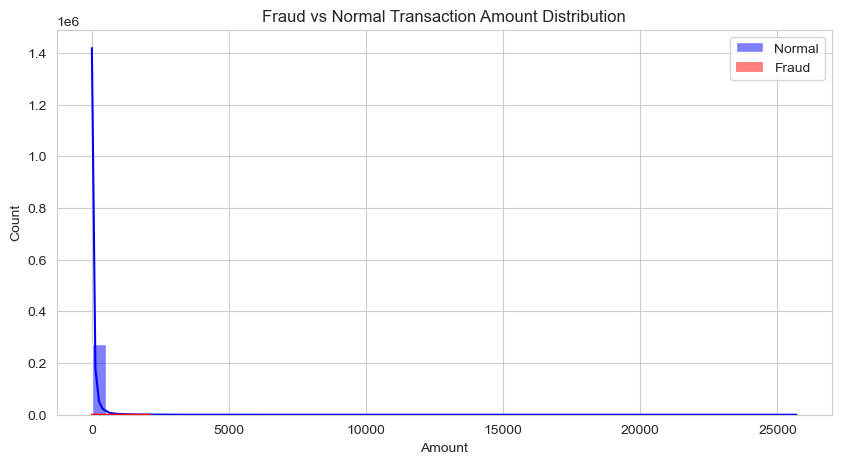

In [7]:
# ============================================================
# Fraud vs Normal Transaction Amount Distribution
# ============================================================
plt.figure(figsize=(10,5))

sns.histplot(df[df["Class"]==0]["Amount"], bins=50, color="blue", label="Normal", kde=True)
sns.histplot(df[df["Class"]==1]["Amount"], bins=50, color="red", label="Fraud", kde=True)

plt.legend()
plt.title("Fraud vs Normal Transaction Amount Distribution")
plt.show()


In [10]:
# ============================================================
# Feature Scaling
# ============================================================
scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(df[["Amount"]])
df["Time"] = scaler.fit_transform(df[["Time"]])


In [11]:
# ============================================================
# Feature Selection
# ============================================================
X = df.drop("Class", axis=1)
y = df["Class"]


In [12]:
# ============================================================
# Train Test Split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Training Shape: (226980, 30)
Test Shape: (56746, 30)


Training Shape After SMOTE: (453204, 30)


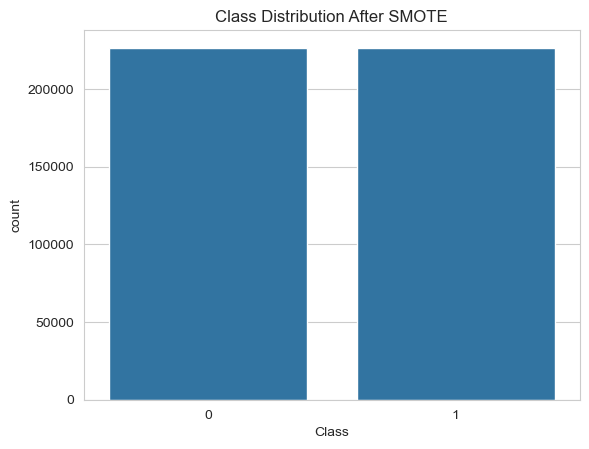

In [13]:
# ============================================================
# Apply SMOTE
# ============================================================
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Training Shape After SMOTE:", X_train_smote.shape)

plt.figure()
sns.countplot(x=y_train_smote)
plt.title("Class Distribution After SMOTE")
plt.show()


In [14]:
# ============================================================
# Random Forest Model
# ============================================================
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

model.fit(X_train_smote, y_train_smote)

print("OOB Score:", model.oob_score_)


OOB Score: 0.9999117395256882


In [15]:
# ============================================================
# Cross Validation
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring="accuracy")
cv_f1 = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring="f1")

print("CV Accuracy:", cv_accuracy.mean())
print("CV F1 Score:", cv_f1.mean())


CV Accuracy: 0.999891880792379
CV F1 Score: 0.9998918943498417


In [26]:
# ============================================================
# Hyperparameter Tuning
# ============================================================
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

best_model = grid_search.best_estimator_


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best F1 Score: 0.9998940992603766


In [28]:
# ============================================================
# Predictions
# ============================================================
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]


In [29]:
# ============================================================
# Evaluation Metrics
# ============================================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

mcc = matthews_corrcoef(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("MCC:", mcc)

print(classification_report(y_test, y_pred))


Accuracy: 0.9994713283755683
Precision: 0.9113924050632911
Recall: 0.7578947368421053
F1: 0.8275862068965517
ROC-AUC: 0.9493554719617529
PR-AUC: 0.8071740151427906
MCC: 0.830854576899801
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



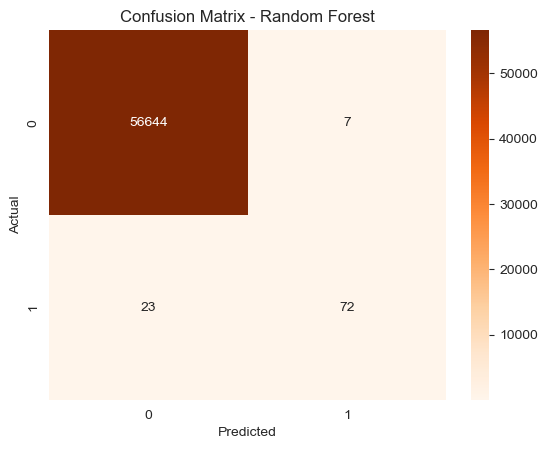

In [30]:
# ============================================================
# Confusion Matrix
# ============================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


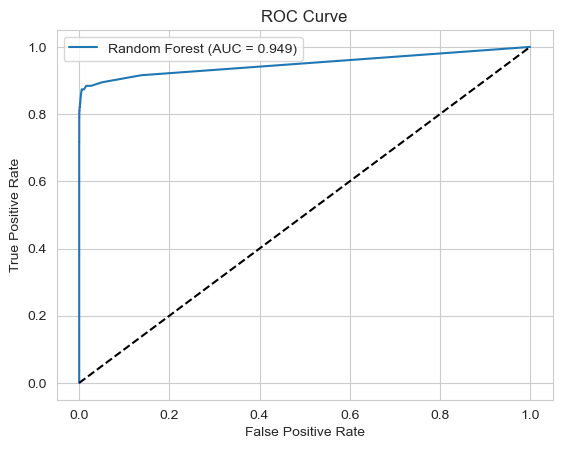

In [31]:
# ============================================================
# ROC Curve
# ============================================================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Random Forest (AUC = %.3f)" % roc_auc)
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()
plt.show()


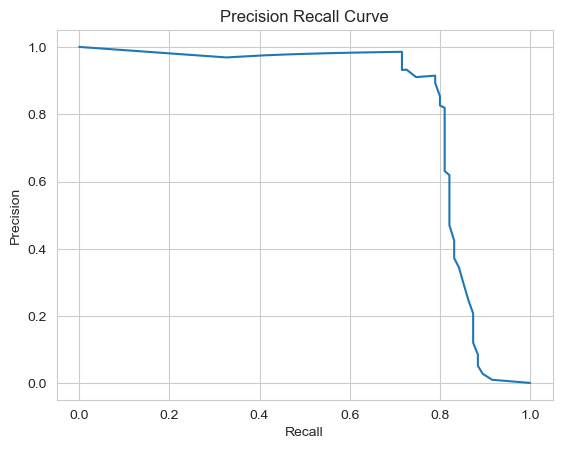

In [32]:
# ============================================================
# Precision Recall Curve
# ============================================================
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall_curve, precision_curve)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")
plt.show()


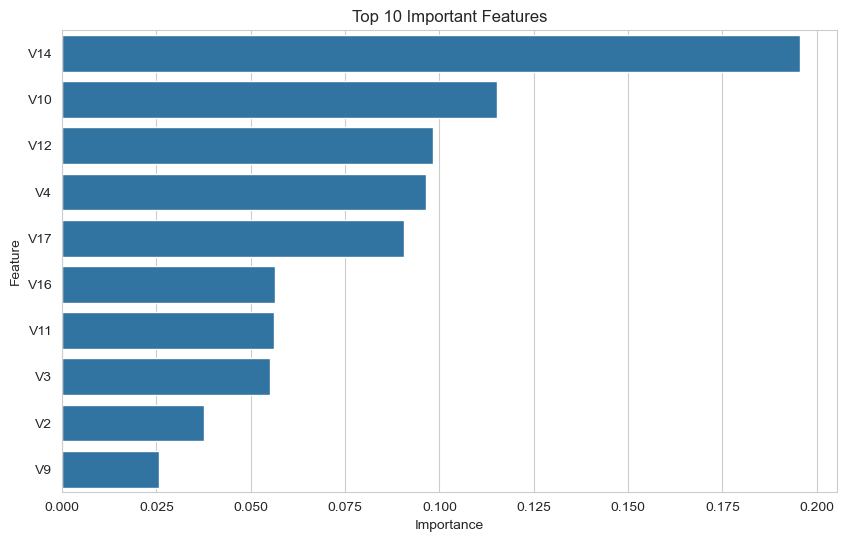

   Feature  Importance
14     V14    0.195579
10     V10    0.115273
12     V12    0.098220
4       V4    0.096484
17     V17    0.090607
16     V16    0.056481
11     V11    0.056183
3       V3    0.055231
2       V2    0.037701
9       V9    0.025575


In [33]:
# ============================================================
# Feature Importance
# ============================================================
importances = best_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

print(importance_df.head(10))


In [34]:
# ============================================================
# FINAL RESULTS SUMMARY
# ============================================================

print("\n=================================================================")
print("RANDOM FOREST – FINAL RESULTS SUMMARY")
print("=================================================================")

print("Dataset              : Credit Card Fraud Detection (Kaggle)")
print("Algorithm            : Random Forest")
print("Total samples        :", len(df))
print("Training samples     :", len(X_train_smote))
print("Test samples         :", len(X_test))
print("Features             :", X.shape[1])

print("-----------------------------------------------------------------")

print("Accuracy                     :", round(accuracy,4))
print("Precision (Fraud)            :", round(precision,4))
print("Recall (Fraud)               :", round(recall,4))
print("F1 Score                     :", round(f1,4))
print("ROC-AUC                      :", round(roc_auc,4))
print("Average Precision (PR-AUC)   :", round(pr_auc,4))
print("Matthews Corr Coefficient    :", round(mcc,4))

print("CV Accuracy (5-Fold)         :", round(cv_accuracy.mean(),4))
print("CV F1 Score (5-Fold)         :", round(cv_f1.mean(),4))

print("=================================================================")



RANDOM FOREST – FINAL RESULTS SUMMARY
Dataset              : Credit Card Fraud Detection (Kaggle)
Algorithm            : Random Forest
Total samples        : 284807
Training samples     : 453204
Test samples         : 56746
Features             : 30
-----------------------------------------------------------------
Accuracy                     : 0.9995
Precision (Fraud)            : 0.9114
Recall (Fraud)               : 0.7579
F1 Score                     : 0.8276
ROC-AUC                      : 0.9494
Average Precision (PR-AUC)   : 0.8072
Matthews Corr Coefficient    : 0.8309
CV Accuracy (5-Fold)         : 0.9999
CV F1 Score (5-Fold)         : 0.9999
